<a href="https://colab.research.google.com/github/MDRobiulhassan/Mental-Health/blob/main/Mental_Health.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [170]:
import numpy as np
import pandas as pd

In [171]:
df=pd.read_csv("/content/drive/MyDrive/University/7th Semester/MLL/Project/Mental Health Dataset.csv")

In [172]:
df.head()

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,8/27/2014 11:29,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,8/27/2014 11:31,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,8/27/2014 11:32,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,8/27/2014 11:37,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,8/27/2014 11:43,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


In [173]:
df.shape

(292364, 17)

In [174]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292364 entries, 0 to 292363
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   Timestamp                292364 non-null  object
 1   Gender                   292364 non-null  object
 2   Country                  292364 non-null  object
 3   Occupation               292364 non-null  object
 4   self_employed            287162 non-null  object
 5   family_history           292364 non-null  object
 6   treatment                292364 non-null  object
 7   Days_Indoors             292364 non-null  object
 8   Growing_Stress           292364 non-null  object
 9   Changes_Habits           292364 non-null  object
 10  Mental_Health_History    292364 non-null  object
 11  Mood_Swings              292364 non-null  object
 12  Coping_Struggles         292364 non-null  object
 13  Work_Interest            292364 non-null  object
 14  Social_Weakness     

# Data Preprocessing

In [175]:
df.isna().sum().T

,0
Timestamp,0
Gender,0
Country,0
Occupation,0
self_employed,5202
family_history,0
treatment,0
Days_Indoors,0
Growing_Stress,0
Changes_Habits,0


In [176]:
df.duplicated().sum()

np.int64(2313)

In [177]:
df = df.drop_duplicates()

In [178]:
df.duplicated().sum()

np.int64(0)

In [179]:
df.isna().sum().T

,0
Timestamp,0
Gender,0
Country,0
Occupation,0
self_employed,5193
family_history,0
treatment,0
Days_Indoors,0
Growing_Stress,0
Changes_Habits,0


In [180]:
df['self_employed'].fillna(df['self_employed'].mode()[0], inplace=True)

/tmp/ipykernel_548/1845955582.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['self_employed'].fillna(df['self_employed'].mode()[0], inplace=True)


In [181]:
df.isna().sum().T

,0
Timestamp,0
Gender,0
Country,0
Occupation,0
self_employed,0
family_history,0
treatment,0
Days_Indoors,0
Growing_Stress,0
Changes_Habits,0


In [182]:
df.describe().T

,count,unique,top,freq
Timestamp,290051,580,8/27/2014 11:43,2381
Gender,290051,2,Male,237900
Country,290051,35,United States,169112
Occupation,290051,5,Housewife,65906
self_employed,290051,2,No,260904
family_history,290051,2,No,175518
treatment,290051,2,Yes,146184
Days_Indoors,290051,5,1-14 days,63113
Growing_Stress,290051,3,Maybe,99300
Changes_Habits,290051,3,Yes,108788


In [183]:
df = df.drop('Timestamp', axis=1)

In [184]:
df.head()

,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,Female,United States,Corporate,No,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


In [185]:
df.dtypes

,0
Gender,object
Country,object
Occupation,object
self_employed,object
family_history,object
treatment,object
Days_Indoors,object
Growing_Stress,object
Changes_Habits,object
Mental_Health_History,object


In [186]:
y = df['treatment'].map({'Yes': 1, 'No': 0})
X = df.drop('treatment', axis=1)

In [187]:
binary_cols = [
    'self_employed',
    'family_history',
    'Coping_Struggles',
    'mental_health_interview',
    'Mental_Health_History',
    'Work_Interest',
    'Social_Weakness'
]

for col in binary_cols:
    X[col] = X[col].map({'Yes': 1, 'No': 0})

In [188]:
X['Gender'] = X['Gender'].map({'Male': 1, 'Female': 0})

In [189]:
X['Mood_Swings'] = X['Mood_Swings'].map({
    'Low': 0,
    'Medium': 1,
    'High': 2
})

In [190]:
X['Days_Indoors'] = X['Days_Indoors'].map({
    '1-14 days': 1,
    '15-30 days': 2,
    '31-60 days': 3,
    'More than 2 months': 4
})

In [191]:
X = pd.get_dummies(X, drop_first=True)

In [192]:
print(X.shape)
print(X.head())
print(X.dtypes.unique())

(290051, 54)
   Gender  self_employed  family_history  Days_Indoors  Mental_Health_History  \
0       0              0               0           1.0                    1.0   
1       0              0               1           1.0                    1.0   
2       0              0               1           1.0                    1.0   
3       0              0               1           1.0                    1.0   
4       0              0               1           1.0                    1.0   

   Mood_Swings  Coping_Struggles  Work_Interest  Social_Weakness  \
0            1                 0            0.0              1.0   
1            1                 0            0.0              1.0   
2            1                 0            0.0              1.0   
3            1                 0            0.0              1.0   
4            1                 0            0.0              1.0   

   mental_health_interview  ...  Occupation_Corporate  Occupation_Housewife  \
0           

In [193]:
df.head()

,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,Female,United States,Corporate,No,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


In [194]:
X.describe()

,Gender,self_employed,family_history,Days_Indoors,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview
count,290051.000000,290051.000000,290051.000000,232070.000000,195535.000000,290051.000000,290051.000000,189667.000000,187474.000000,238510.000000
mean,0.820201,0.100489,0.394872,2.464493,0.471639,0.970140,0.472400,0.446335,0.485385,0.036145
std,0.384021,0.300652,0.488824,1.127083,0.499196,0.808096,0.499239,0.497113,0.499788,0.186652
min,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000,2.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,3.000000,1.000000,2.000000,1.000000,1.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,4.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000


In [195]:
y.describe()

,treatment
count,290051.000000
mean,0.503994
std,0.499985
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


In [196]:
y.value_counts()

,count
treatment,
1,146184
0,143867


In [197]:
import pandas as pd

numeric_cols = X.select_dtypes(include='number').columns

outlier_summary = []

for col in numeric_cols:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = ((X[col] < lower) | (X[col] > upper)).sum()

    if outlier_count > 0:
        outlier_summary.append({
            'feature': col,
            'Q1': Q1,
            'Q3': Q3,
            'lower_bound': lower,
            'upper_bound': upper,
            'outlier_count': outlier_count
        })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df.sort_values(by="outlier_count", ascending=False)

,feature,Q1,Q3,lower_bound,upper_bound,outlier_count
0,Gender,1.0,1.0,1.0,1.0,52151
1,self_employed,0.0,0.0,0.0,0.0,29147
2,mental_health_interview,0.0,0.0,0.0,0.0,8621


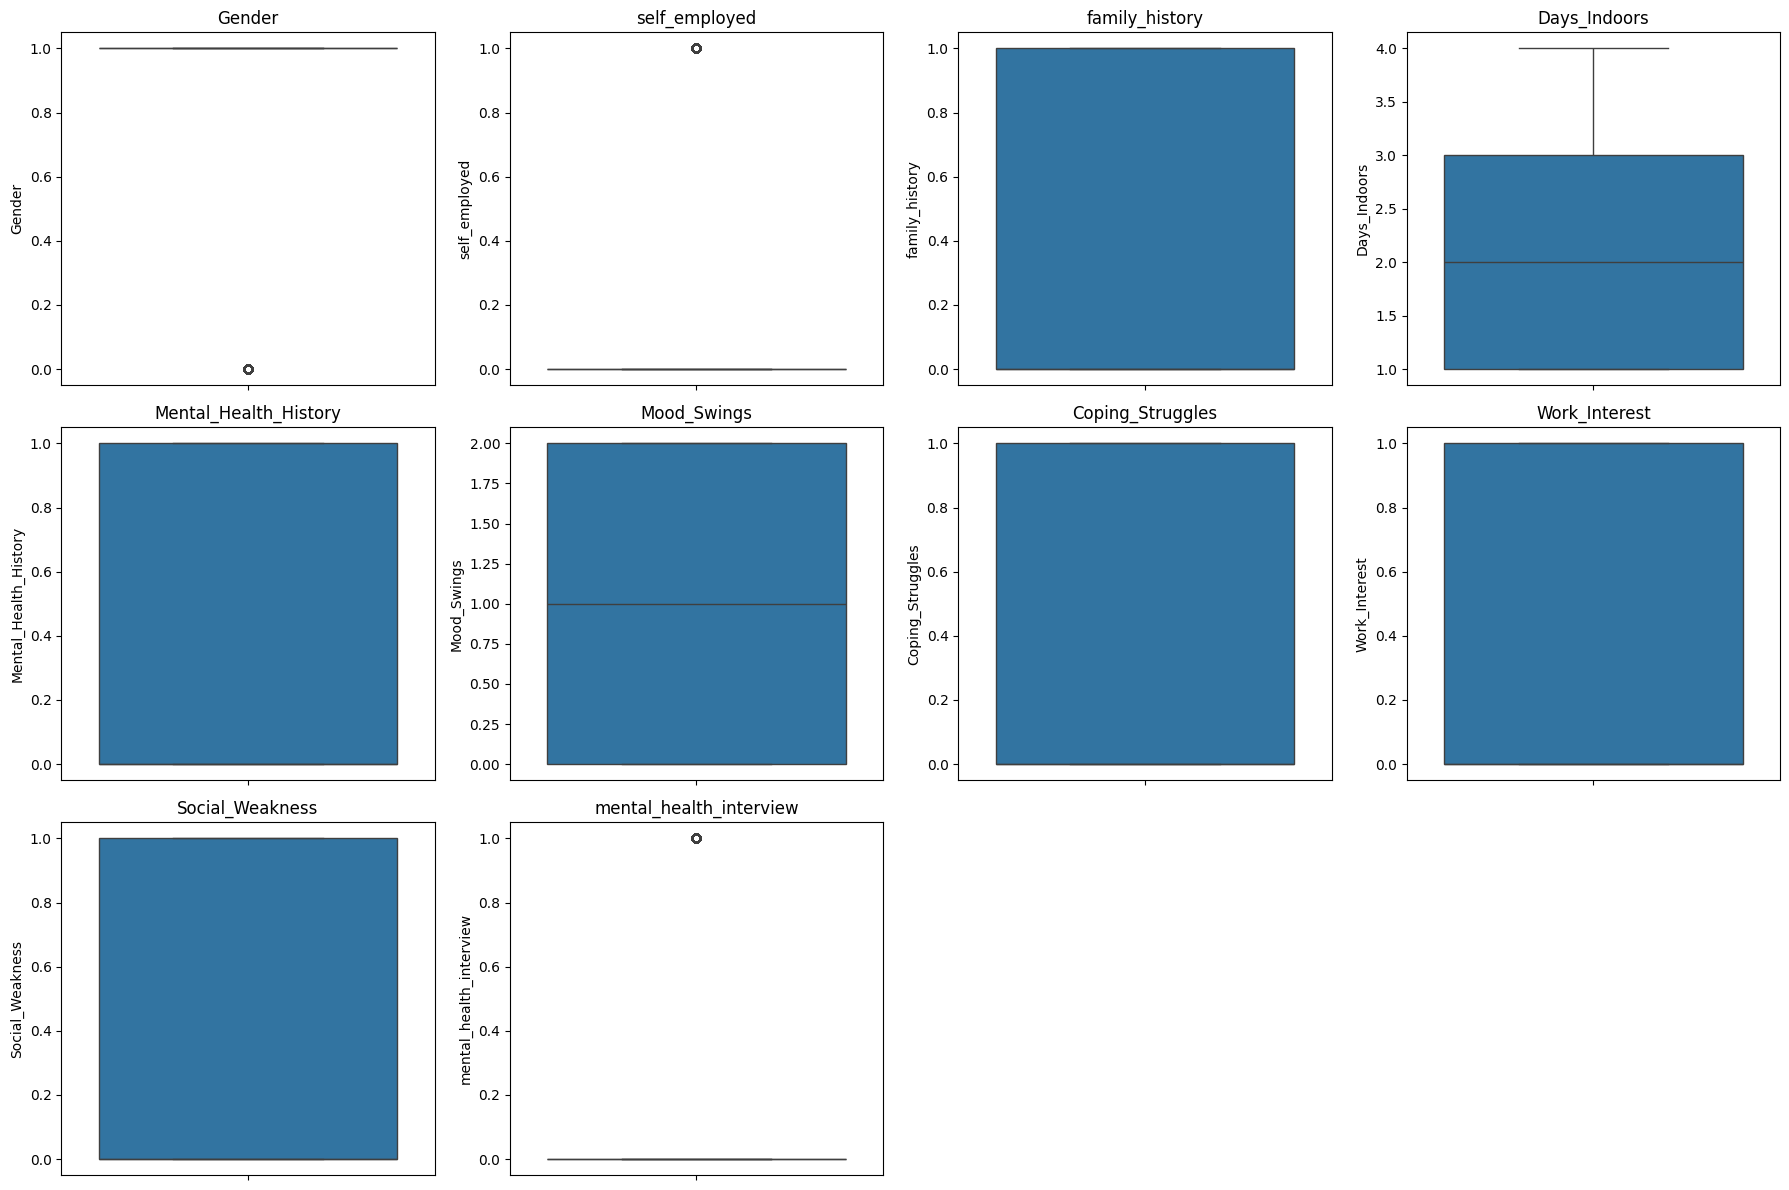

In [198]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_features = X.select_dtypes(include='number').columns

cols = 4
rows = (len(numeric_features) // cols) + 1

fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    sns.boxplot(y=X[feature], ax=axes[i])
    axes[i].set_title(feature)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [199]:
X.isnull().sum()

,0
Gender,0
self_employed,0
family_history,0
Days_Indoors,57981
Mental_Health_History,94516
Mood_Swings,0
Coping_Struggles,0
Work_Interest,100384
Social_Weakness,102577
mental_health_interview,51541


In [200]:
X = X.fillna(X.mode().iloc[0])

In [201]:
X.isnull().sum()

,0
Gender,0
self_employed,0
family_history,0
Days_Indoors,0
Mental_Health_History,0
Mood_Swings,0
Coping_Struggles,0
Work_Interest,0
Social_Weakness,0
mental_health_interview,0


In [202]:
X.head()

,Gender,self_employed,family_history,Days_Indoors,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,...,Occupation_Corporate,Occupation_Housewife,Occupation_Others,Occupation_Student,Growing_Stress_No,Growing_Stress_Yes,Changes_Habits_No,Changes_Habits_Yes,care_options_Not sure,care_options_Yes
0,0,0,0,1.0,1.0,1,0,0.0,1.0,0.0,...,True,False,False,False,False,True,True,False,True,False
1,0,0,1,1.0,1.0,1,0,0.0,1.0,0.0,...,True,False,False,False,False,True,True,False,False,False
2,0,0,1,1.0,1.0,1,0,0.0,1.0,0.0,...,True,False,False,False,False,True,True,False,False,True
3,0,0,1,1.0,1.0,1,0,0.0,1.0,0.0,...,True,False,False,False,False,True,True,False,False,True
4,0,0,1,1.0,1.0,1,0,0.0,1.0,0.0,...,True,False,False,False,False,True,True,False,False,True


In [205]:
X = X.astype(int)

In [206]:
X.head()

,Gender,self_employed,family_history,Days_Indoors,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,...,Occupation_Corporate,Occupation_Housewife,Occupation_Others,Occupation_Student,Growing_Stress_No,Growing_Stress_Yes,Changes_Habits_No,Changes_Habits_Yes,care_options_Not sure,care_options_Yes
0,0,0,0,1,1,1,0,0,1,0,...,1,0,0,0,0,1,1,0,1,0
1,0,0,1,1,1,1,0,0,1,0,...,1,0,0,0,0,1,1,0,0,0
2,0,0,1,1,1,1,0,0,1,0,...,1,0,0,0,0,1,1,0,0,1
3,0,0,1,1,1,1,0,0,1,0,...,1,0,0,0,0,1,1,0,0,1
4,0,0,1,1,1,1,0,0,1,0,...,1,0,0,0,0,1,1,0,0,1
